# Problem 2.6: Audio Downsampling (Decimation) and Aliasing

### Problem Statement:
This problem uses the sound file `handel` available in MATLAB. This sound is sampled at $F_s = 8192$ samples per second using 8-bits per sample.
* **(a)** Load the `handel` sound and listen to it at the full sampling rate ($F_s = 8192$ Hz).
* **(b)** Downsample by a factor of 2: select every other sample ($x[2n]$), set $F_s = 4096$ Hz, and listen to the result.
* **(c)** Downsample by a factor of 4: select every fourth sample ($x[4n]$), set $F_s = 2048$ Hz, listen to the sound, and save the downsampled file.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display


## (a) Load and Listen to Original Audio ($F_s = 8192$ Hz)

In [3]:
wav_path = Path('handel.wav')
x, Fs = sf.read(wav_path)

print(f"Original sampling rate: {Fs} Hz")
print(f"Number of samples: {len(x)}")
print(f"Duration: {len(x) / Fs:.2f} seconds")

# In-notebook audio player
display(Audio(data=x, rate=int(Fs)))


Original sampling rate: 8192 Hz
Number of samples: 73113
Duration: 8.92 seconds


## (b) Downsample by a Factor of 2 ($F_s = 4096$ Hz)

In [4]:
x_half = x[::2]
Fs_half = Fs / 2

print(f"Downsampled by 2: Fs = {Fs_half} Hz, samples = {len(x_half)}")
display(Audio(data=x_half, rate=int(Fs_half)))


Downsampled by 2: Fs = 4096.0 Hz, samples = 36557


## (c) Downsample by a Factor of 4 ($F_s = 2048$ Hz) & Export

In [ ]:
x_quarter = x[::4]
Fs_quarter = Fs / 4

print(f"Downsampled by 4: Fs = {Fs_quarter} Hz, samples = {len(x_quarter)}")
display(Audio(data=x_quarter, rate=Fs_quarter))

# Save the downsampled sound file
output_path = Path('handel_quarter.wav')
sf.write(output_path, x_quarter, int(Fs_quarter))
print(f"Saved to {output_path}")

Downsampled by 4: Fs = 2048.0 Hz, samples = 18279


Saved to handel_quarter.wav


## Waveform Comparison

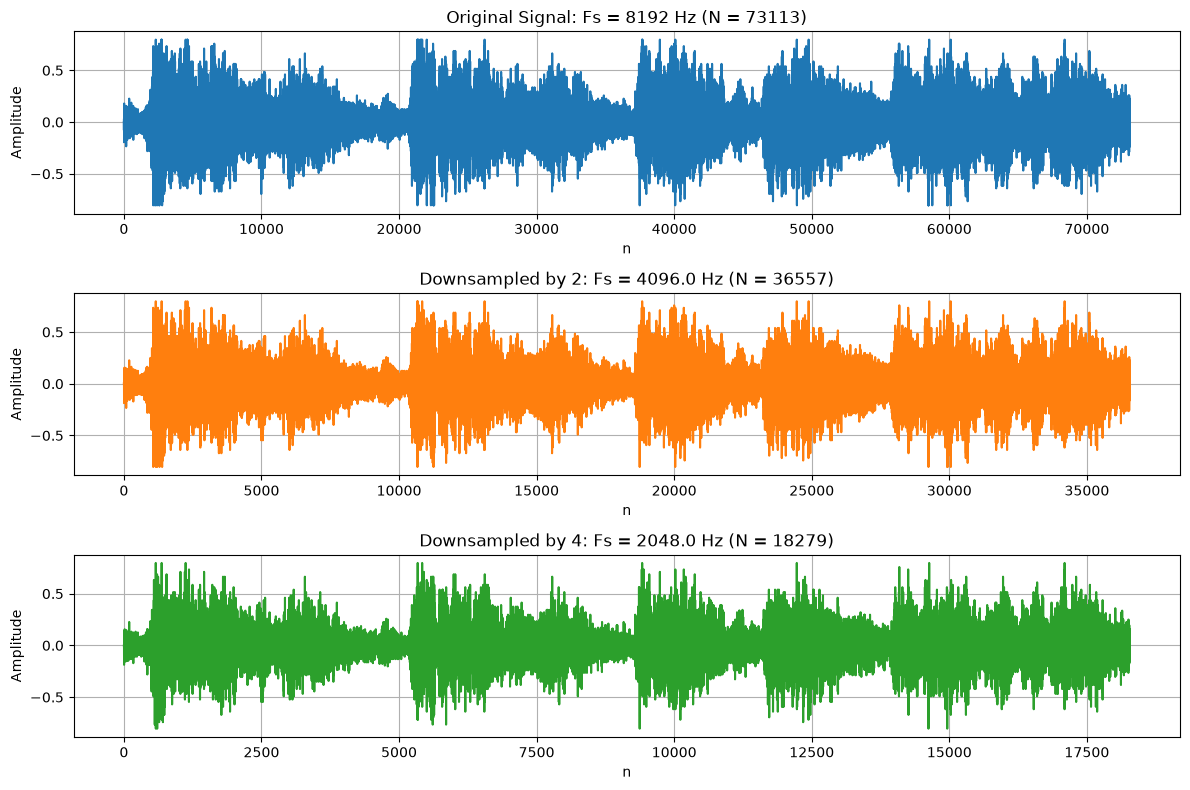

In [6]:
n = np.arange(len(x))
n_half = np.arange(len(x_half))
n_quarter = np.arange(len(x_quarter))

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(n, x, color='tab:blue')
plt.title(f'Original Signal: Fs = {Fs} Hz (N = {len(x)})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(n_half, x_half, color='tab:orange')
plt.title(f'Downsampled by 2: Fs = {Fs_half} Hz (N = {len(x_half)})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(n_quarter, x_quarter, color='tab:green')
plt.title(f'Downsampled by 4: Fs = {Fs_quarter} Hz (N = {len(x_quarter)})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()
